In [21]:
# =============================================================================
# 1. INSTALAÇÃO E IMPORTAÇÃO DE BIBLIOTECAS
# =============================================================================
!pip install -q shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)
import shap

# Importação da função da Parte 1
from histograma_grafico_e_faixas import gerar_grafico_e_metricas

In [22]:
# =============================================================================
# 2. CARREGAMENTO E EXTRAÇÃO DO IDENTIFICADOR DE SUJEITO
# =============================================================================
caminho_arquivo = 'base-dados-parkinson (2).csv'
df = pd.read_csv(caminho_arquivo)

# Extrai o identificador do sujeito a partir da coluna 'name' (ex: phon_R01_S01_1 -> S01)
df['subject_id'] = df['name'].apply(lambda x: x.split('_')[2])

X = df.drop(columns=['name', 'status', 'subject_id'])
y = df['status']
groups = df['subject_id']

# Checagem da proporção das classes na base completa
contagem_classes = df.groupby("status")["status"].count()
porcentagem_classes = contagem_classes / contagem_classes.sum() * 100

print(f"Total de registros: {len(df)} | Total de sujeitos: {len(groups.unique())}")
print("Distribuição das classes (%):")
print(porcentagem_classes)

Total de registros: 195 | Total de sujeitos: 32
Distribuição das classes (%):
status
0    24.615385
1    75.384615
Name: status, dtype: float64


In [23]:
# =============================================================================
# 3. DIVISÃO EM DESENVOLVIMENTO E TESTE VIA STRATIFIED GROUP K-FOLD
# =============================================================================
# Divisão a nível de sujeito para evitar vazamento de dados
sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=2)
train_idx, test_idx = next(sgkf_test.split(X, y, groups))

X_dev, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_dev, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_dev = groups.iloc[train_idx].copy()

print(f"Instâncias de Desenvolvimento: {X_dev.shape[0]} ({len(groups_dev.unique())} sujeitos)")
print(f"Instâncias de Teste Reservado  : {X_test.shape[0]} ({len(groups.iloc[test_idx].unique())} sujeitos)")

Instâncias de Desenvolvimento: 153 (25 sujeitos)
Instâncias de Teste Reservado  : 42 (7 sujeitos)


In [20]:
# =============================================================================
# 4. VALIDAÇÃO CRUZADA E HIPERPARÂMETROS (F1-SCORE COMO MÉTRICA-ALVO)
# =============================================================================
cv_dev = StratifiedGroupKFold(n_splits=5)

# Pipelines com StandardScaler
pipe_lr = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42))])
pipe_rf = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))])
pipe_svm = Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))])

# Grids de Hiperparâmetros
param_lr = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],
    'clf__class_weight': [None, 'balanced']
}
param_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5, 10, None],
    'clf__class_weight': [None, 'balanced']
}
param_svm = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__gamma': ['scale', 'auto', 0.1],
    'clf__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(pipe_lr, param_lr, scoring='f1', cv=cv_dev, n_jobs=-1)
grid_rf = GridSearchCV(pipe_rf, param_rf, scoring='f1', cv=cv_dev, n_jobs=-1)
grid_svm = GridSearchCV(pipe_svm, param_svm, scoring='f1', cv=cv_dev, n_jobs=-1)

grid_lr.fit(X_dev, y_dev, groups=groups_dev)
grid_rf.fit(X_dev, y_dev, groups=groups_dev)
grid_svm.fit(X_dev, y_dev, groups=groups_dev)

print("Resultados da Validação Cruzada Agrupada (F1 Médio):")
print(f"Regressão Logística : {grid_lr.best_score_:.4f} | Melhores params: {grid_lr.best_params_}")
print(f"Random Forest       : {grid_rf.best_score_:.4f} | Melhores params: {grid_rf.best_params_}")
print(f"SVM (RBF)           : {grid_svm.best_score_:.4f} | Melhores params: {grid_svm.best_params_}")

Resultados da Validação Cruzada Agrupada (F1 Médio):
Regressão Logística : 0.9490 | Melhores params: {'clf__C': 0.1, 'clf__class_weight': None}
Random Forest       : 0.9615 | Melhores params: {'clf__class_weight': None, 'clf__max_depth': 5, 'clf__n_estimators': 100}
SVM (RBF)           : 0.9457 | Melhores params: {'clf__C': 10.0, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale'}


Limiar de decisão utilizado: 0.5
                     Acurácia  Precisão  Recall      F1  AUC-ROC  \
Modelo                                                             
Regressão Logística    0.5714    0.5000  1.0000  0.6667   0.4630   
Random Forest          0.4762    0.4375  0.7778  0.5600   0.5556   
SVM (RBF)              0.5714    0.5000  1.0000  0.6667   0.4120   

                     AUC-PR (trapz)      AP      TN/FP/FN/TP  
Modelo                                                        
Regressão Logística          0.4598  0.4735  6 / 18 / 0 / 18  
Random Forest                0.5257  0.5430  6 / 18 / 4 / 14  
SVM (RBF)                    0.3585  0.3848  6 / 18 / 0 / 18  


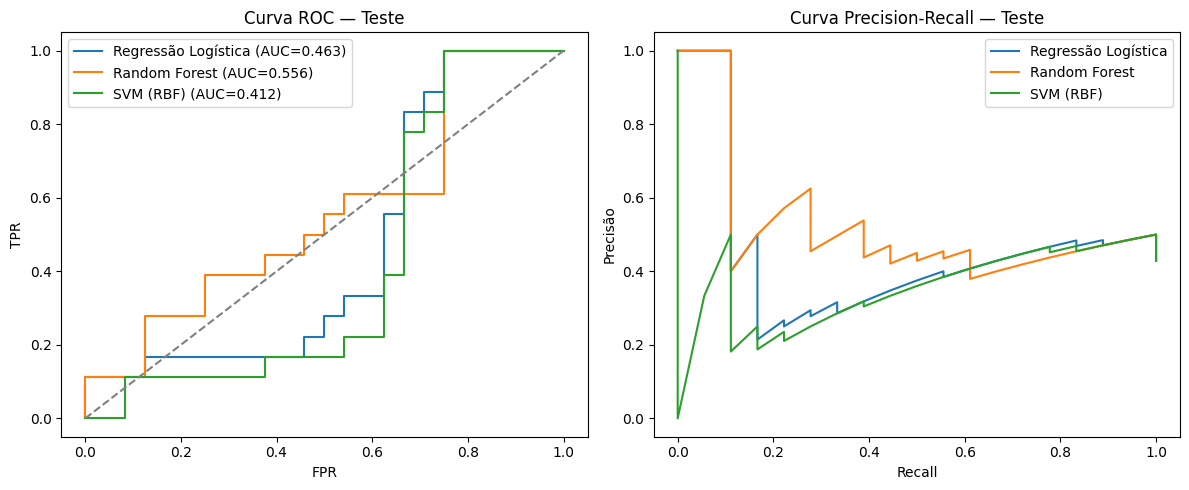

In [24]:
# =============================================================================
# 5. AVALIAÇÃO DE DESEMPENHO NO TESTE (LIMIAR = 0.50) E GRÁFICOS
# =============================================================================
LIMIAR = 0.50
modelos = {
    "Regressão Logística": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "SVM (RBF)": grid_svm.best_estimator_
}

resultados_teste = []
curvas = {}

for nome, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= LIMIAR).astype(int)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr_trapz = auc(rec_c, prec_c)
    ap = average_precision_score(y_test, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    resultados_teste.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": auc_roc,
        "AUC-PR (trapz)": auc_pr_trapz,
        "AP": ap,
        "TN/FP/FN/TP": f"{tn} / {fp} / {fn} / {tp}"
    })

    curvas[nome] = dict(fpr=fpr, tpr=tpr, recall=rec_c, precisao=prec_c, auc_roc=auc_roc)

tabela_comparativa = pd.DataFrame(resultados_teste).set_index("Modelo").round(4)
print(f"Limiar de decisão utilizado: {LIMIAR}")
print(tabela_comparativa)

# Plotagem das Curvas ROC e Precision-Recall
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for nome, c in curvas.items():
    eixos[0].plot(c["fpr"], c["tpr"], label=f"{nome} (AUC={c['auc_roc']:.3f})")
    eixos[1].plot(c["recall"], c["precisao"], label=nome)

eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC — Teste")
eixos[0].set_xlabel("FPR")
eixos[0].set_ylabel("TPR")
eixos[0].legend()

eixos[1].set_title("Curva Precision-Recall — Teste")
eixos[1].set_xlabel("Recall")
eixos[1].set_ylabel("Precisão")
eixos[1].legend()

plt.tight_layout()
plt.show()

  0%|          | 0/42 [00:00<?, ?it/s]

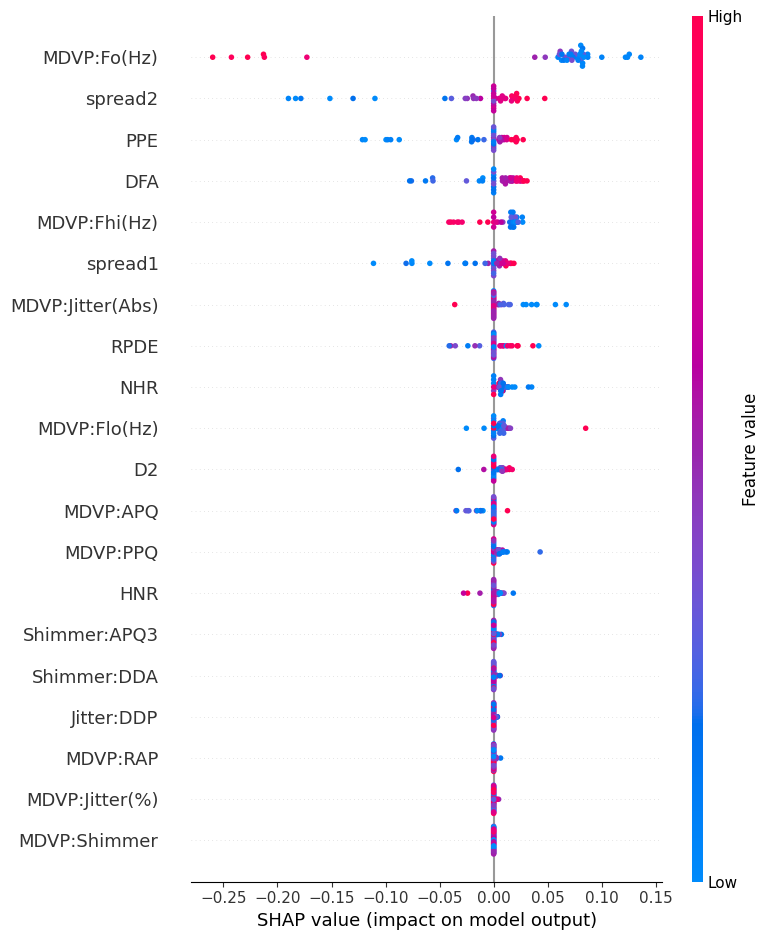

In [26]:
# =============================================================================
# 6. EXPLICABILIDADE SHAP (BEESWARM) PARA O MELHOR MODELO [SVM (RBF)]
# =============================================================================
melhor_modelo_svm = grid_svm.best_estimator_
scaler_dev = melhor_modelo_svm.named_steps['scaler']
clf_svm = melhor_modelo_svm.named_steps['clf']

X_dev_scaled = pd.DataFrame(scaler_dev.transform(X_dev), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler_dev.transform(X_test), columns=X.columns)

# Fundo com k-means nos dados de desenvolvimento
background_summary = shap.kmeans(X_dev_scaled, 20)
explainer = shap.KernelExplainer(clf_svm.predict_proba, background_summary)
shap_values = explainer.shap_values(X_test_scaled)

# Tratamento para garantir o formato correto da classe positiva (Parkinson = 1)
if isinstance(shap_values, list):
    # Formato antigo: lista [classe_0, classe_1]
    values_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Formato novo: array 3D (amostras, características, classes)
    values_pos = shap_values[:, :, 1]
elif hasattr(shap_values, "values") and shap_values.values.ndim == 3:
    # Objeto Explanation 3D
    values_pos = shap_values.values[:, :, 1]
else:
    values_pos = shap_values

# Gráfico Beeswarm da classe positiva (Parkinson)
plt.figure(figsize=(10, 6))
shap.summary_plot(values_pos, X_test_scaled, show=True)

--- HISTOGRAMA E FAIXAS NA VALIDAÇÃO ---


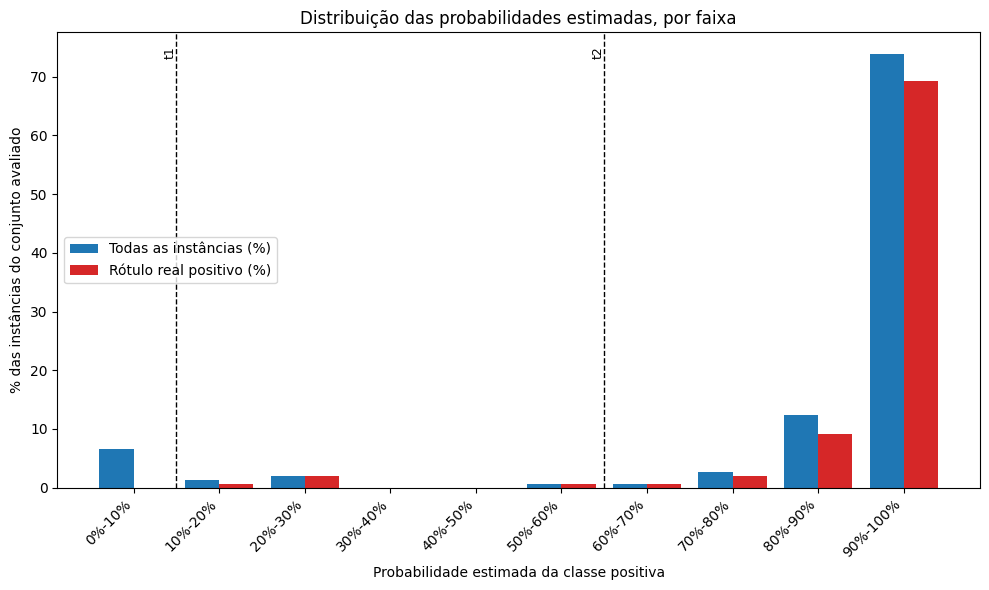


--- HISTOGRAMA E FAIXAS NO TESTE ---


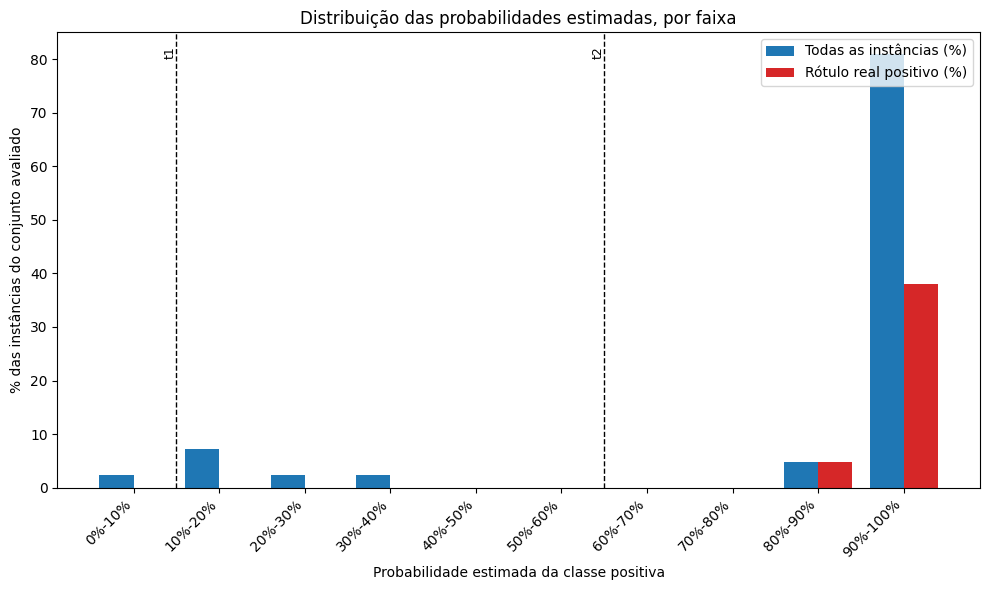

In [27]:
# =============================================================================
# 7. APLICAÇÃO DO PROGRAMA DA PARTE 1 (CORTES t1 = 10% E t2 = 60%)
# =============================================================================
# Probabilidades Out-of-fold (fora da amostra) na validação
oof_probs = np.zeros(len(X_dev))
for train_fold_idx, val_fold_idx in cv_dev.split(X_dev, y_dev, groups_dev):
    pipe_fold = Pipeline([('scaler', StandardScaler()), ('clf', SVC(C=1.0, gamma='scale', probability=True, random_state=42))])
    pipe_fold.fit(X_dev.iloc[train_fold_idx], y_dev.iloc[train_fold_idx])
    oof_probs[val_fold_idx] = pipe_fold.predict_proba(X_dev.iloc[val_fold_idx])[:, 1]

print("--- HISTOGRAMA E FAIXAS NA VALIDAÇÃO ---")
fig_val, ax_val, tab_val, met_val = gerar_grafico_e_metricas(
    y_true=y_dev, y_proba=oof_probs, bin_width=10, t1=10.0, t2=60.0
)
plt.show()

print("\n--- HISTOGRAMA E FAIXAS NO TESTE ---")
test_probs = melhor_modelo_svm.predict_proba(X_test)[:, 1]
fig_test, ax_test, tab_test, met_test = gerar_grafico_e_metricas(
    y_true=y_test, y_proba=test_probs, bin_width=10, t1=10.0, t2=60.0
)
plt.show()